# Perturbing a Bistable Model: Switching States

In [1]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown
# (requires ipywidgets: pip install ipywidgets)

%matplotlib inline
# Use the lightweight static (inline) backend here, not an interactive one such as
# '%matplotlib widget'/ipympl -- those keep a persistent live canvas per figure and
# are the other common cause of the kernel freezing after repeated slider moves.


In [2]:
def forward_inhibition_open_model(variables, time, parameters):
    
    S, P = variables[0], variables[1]
    
    k_max, K_m, n, m   = parameters[0], parameters[1], parameters[2], parameters[3]
    a_s, a_p, b_s, b_p = parameters[4], parameters[5], parameters[6], parameters[7]

    rate = k_max*S**n/(K_m + S**m)
    
    dS_dt  = a_s - b_s*S - rate
    dP_dt  = a_p - b_p*P + rate
    
    return [dS_dt, dP_dt]

In [1]:
# # Bistable parameter set
# # NOTE: in forward_inhibition_open_model the unpacking order is
# #       a_s, a_p, b_s, b_p = parameters[4], parameters[5], parameters[6], parameters[7]
# n, m = 1, 3
# k_max, K_m         = 2, 0.5
# a_s, a_p, b_s, b_p = 1.2, 0.2, 0.3, 0.4
# parameters = [k_max, K_m, n, m, a_s, a_p, b_s, b_p]

# # The two stable steady states for this parameter set (found by locating the
# # roots of a_s - b_s*S - rate(S) = 0 and checking their sign of df/dS):
# #   low  state:  S* ~ 0.35,  P* ~ 3.74
# #   high state:  S* ~ 4.31,  P* ~ 0.77
# # with an unstable state in between at S* ~ 1.24 (the switching threshold)
# S_low  = [0.29, 3.28]
# S_high = [3.45, 0.92]

# # Pulse timing
# pulse_start    = 5
# pulse_duration = 2
# t_total        = 40
# time_step      = 0.05


# def simulate_with_pulse(amplitude, variables_init):
#     """
#     Integrate the model with a rectangular pulse added to a_s (i.e. a temporary
#     extra influx/efflux of S) of the given amplitude, applied between
#     pulse_start and pulse_start + pulse_duration. Returns the full time course.
#     """
#     # before the pulse: normal a_s
#     t1   = np.arange(0, pulse_start, time_step)
#     sol1 = odeint(forward_inhibition_open_model, variables_init, t1,
#                   args=([k_max, K_m, n, m, a_s, a_p, b_s, b_p],))

#     # during the pulse: a_s -> a_s + amplitude
#     t2   = np.arange(pulse_start, pulse_start + pulse_duration, time_step)
#     sol2 = odeint(forward_inhibition_open_model, sol1[-1], t2,
#                   args=([k_max, K_m, n, m, a_s + amplitude, a_p, b_s, b_p],))

#     # after the pulse: back to the original a_s
#     t3   = np.arange(pulse_start + pulse_duration, t_total, time_step)
#     sol3 = odeint(forward_inhibition_open_model, sol2[-1], t3,
#                   args=([k_max, K_m, n, m, a_s, a_p, b_s, b_p],))

#     time      = np.concatenate([t1, t2, t3])
#     variables = np.vstack([sol1, sol2, sol3])
#     return time, variables


# def plot_pulse_response(amplitude=1.0, start_state='low'):

#     plt.close('all')  # drop any figure(s) from the previous call -- otherwise they
#                        # pile up in memory on every slider move / cell re-run and
#                        # eventually freeze the kernel

#     variables_init = S_low if start_state == 'low' else S_high
#     time, variables = simulate_with_pulse(amplitude, variables_init)

#     fig, ax = plt.subplots()

#     ax.axvspan(pulse_start, pulse_start + pulse_duration,
#                color='grey', alpha=0.2, label='pulse')

#     ax.axhline(S_low[0],  color='tomato', linestyle=':', linewidth=1)
#     ax.axhline(S_high[0], color='tomato', linestyle=':', linewidth=1)

#     ax.plot(time, variables[:, 0], c='tomato',      label='S')
#     ax.plot(time, variables[:, 1], c='deepskyblue', label='P')

#     outcome = 'swapped' if abs(variables[-1, 0] - variables_init[0]) > 0.5 else 'returned'
#     ax.set_xlabel('time')
#     ax.set_ylabel('Amount')
#     ax.set_title(f'amplitude={amplitude:.2f}, start={start_state}  ->  {outcome} '
#                  f'(final S={variables[-1, 0]:.2f})')
#     ax.set_ylim(-0.1, 6)
#     ax.legend(loc='upper right')
#     plt.show()

# # Slider re-runs the simulation and redraws the plot on every change.
# # Roughly: |amplitude| > ~0.8 (from 'low') or > ~1.6 (from 'high') is enough to swap state.
# interact(plot_pulse_response,
#           amplitude=FloatSlider(min=-1.5, max=2.5, step=0.1, value=1.0,
#                                  description='pulse amp.'),
#           start_state=Dropdown(options=['low', 'high'], value='low',
#                                 description='start at'));

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

%matplotlib inline

n, m = 1, 3
k_max, K_m         = 2, 0.5
a_s, a_p, b_s, b_p = 1.2, 0.2, 0.3, 0.4
parameters = [k_max, K_m, n, m, a_s, a_p, b_s, b_p]

# The two stable steady states for this parameter set (found by locating the
# roots of a_s - b_s*S - rate(S) = 0 and checking their sign of df/dS):
#   low  state:  S* ~ 0.35,  P* ~ 3.74
#   high state:  S* ~ 4.31,  P* ~ 0.77
# with an unstable state in between at S* ~ 1.24 (the switching threshold)
S_low  = [0.29, 3.28]
S_high = [3.45, 0.92]

# Noise-induced switching
#
# odeint can't take a stochastic forcing term, so this cell integrates the
# model with a fixed-step Euler-Maruyama scheme instead (reusing the same
# k_max, K_m, n, m, a_s, a_p, b_s, b_p, S_low, S_high defined in the pulse
# cell above):
#
#   dS = [a_s - b_s*S - rate(S)] dt + sigma*sqrt(S)*dW
#   dP = [a_p - b_p*P + rate(S)] dt
#
# The noise sits on the S balance only (representing a fluctuating supply)
# and is scaled by sqrt(S) -- the standard "chemical Langevin" convention --
# so it automatically shrinks to zero as S -> 0 and can't itself drive S
# negative. A hard floor at 0 is kept only as a numerical safety net.
#
# Run time is much longer than the pulse demo (noise-induced switching is a
# rare event that needs time to happen), and the step dt_noise must stay
# small for the Euler-Maruyama scheme to be accurate.

t_total_noise = 300
dt_noise      = 0.01


def simulate_with_noise(sigma, variables_init, seed):
    """Euler-Maruyama integration of forward_inhibition_open_model with
    multiplicative noise sigma*sqrt(S) added to the S balance."""

    rng = np.random.default_rng(seed)

    n_steps = int(t_total_noise / dt_noise)
    time    = np.arange(n_steps + 1) * dt_noise
    sqrt_dt = np.sqrt(dt_noise)

    S = np.empty(n_steps + 1)
    P = np.empty(n_steps + 1)
    S[0], P[0] = variables_init

    for i in range(n_steps):
        rate_i = k_max * S[i]**n / (K_m + S[i]**m)

        dS = (a_s - b_s*S[i] - rate_i) * dt_noise \
             + sigma * np.sqrt(S[i]) * sqrt_dt * rng.standard_normal()
        dP = (a_p - b_p*P[i] + rate_i) * dt_noise

        S[i + 1] = max(S[i] + dS, 0.0)   # safety floor, see note above
        P[i + 1] = max(P[i] + dP, 0.0)

    return time, np.column_stack([S, P])


def plot_noise_response(sigma=0.0, start_state='low', seed=0):

    plt.close('all')  # avoid accumulating figures across slider moves / re-runs

    variables_init = S_low if start_state == 'low' else S_high
    time, variables = simulate_with_noise(sigma, variables_init, seed)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.axhline(S_low[0],  color='tomato', linestyle=':', linewidth=1)
    ax.axhline(S_high[0], color='tomato', linestyle=':', linewidth=1)

    ax.plot(time, variables[:, 0], c='tomato',      label='S', linewidth=0.8)
    ax.plot(time, variables[:, 1], c='deepskyblue', label='P', linewidth=0.8)

    outcome = 'switched' if abs(variables[-1, 0] - variables_init[0]) > 0.5 else 'stayed'
    ax.set_xlabel('time')
    ax.set_ylabel('Amount')
    ax.set_title(f'sigma={sigma:.2f}, start={start_state}, seed={seed}  ->  {outcome} '
                 f'(final S={variables[-1, 0]:.2f})')
    ax.set_ylim(-0.1, 10)
    ax.legend(loc='upper right')
    plt.show()


# 'seed' is a "reseed" control: the same (sigma, start_state, seed) combination
# always reproduces the same trace, so you can compare noise amplitudes fairly --
# but moving seed at a fixed sigma draws a fresh realization, showing that
# switching is a probabilistic event (e.g. sigma~1.2 switches roughly 1 time in 3
# over this run length, with these parameters).
# continuous_update=False means each slider only triggers a re-run on release,
# not on every pixel of drag, since each run takes ~0.1s.
interact(plot_noise_response,
          sigma=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0,
                             description='noise sigma', continuous_update=False),
          start_state=Dropdown(options=['low', 'high'], value='low',
                                description='start substrate'),
          seed=IntSlider(min=30, max=50, step=1, value=0,
                          description='seed', continuous_update=False));

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='noise sigma', max=1.0, step…

``` + sigma * np.sqrt(S[i]) * sqrt_dt * rng.standard_normal()```

the stochastic (diffusion) term of the Euler–Maruyama update.

For an SDE dX = f(X)dt + g(X)dW, Euler–Maruyama discretizes it as:

X[i+1] = X[i] + f(X[i])·dt + g(X[i])·√dt·Z, where Z ~ N(0,1)

The √dt scaling is the key piece — it's there because a Wiener increment dW has standard deviation √dt, not dt (variance grows linearly with time, so standard deviation grows with its square root). rng.standard_normal() draws the Z, and sqrt_dt supplies the √dt, so sqrt_dt * rng.standard_normal() together approximate one increment of dW.

In our case g(S) = sigma·√S, so the full term sigma * np.sqrt(S[i]) * sqrt_dt * rng.standard_normal() is g(S[i])·√dt·Z — the diffusion term for that step. The sigma*np.sqrt(S[i])*dt part (deterministic, no sqrt_dt) would be wrong; it has to be sqrt_dt, not dt, for the noise to converge to a proper continuous-time process as you shrink the step size.

# Noisy Time Series

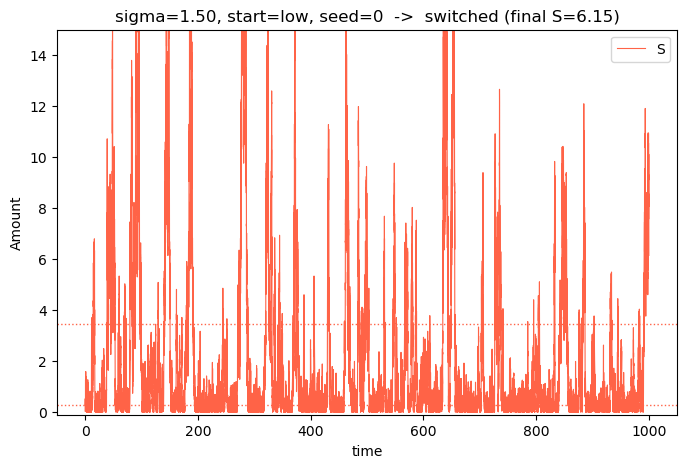

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

%matplotlib inline

n, m = 1, 3
k_max, K_m         = 2, 0.5
a_s, a_p, b_s, b_p = 1.2, 0.2, 0.3, 0.4
parameters = [k_max, K_m, n, m, a_s, a_p, b_s, b_p]

# The two stable steady states for this parameter set (found by locating the
# roots of a_s - b_s*S - rate(S) = 0 and checking their sign of df/dS):
#   low  state:  S* ~ 0.35,  P* ~ 3.74
#   high state:  S* ~ 4.31,  P* ~ 0.77
# with an unstable state in between at S* ~ 1.24 (the switching threshold)
S_low  = [0.29, 3.28]
S_high = [3.45, 0.92]

# Noise-induced switching
#
# odeint can't take a stochastic forcing term, so this cell integrates the
# model with a fixed-step Euler-Maruyama scheme instead (reusing the same
# k_max, K_m, n, m, a_s, a_p, b_s, b_p, S_low, S_high defined in the pulse
# cell above):
#
#   dS = [a_s - b_s*S - rate(S)] dt + sigma*sqrt(S)*dW
#   dP = [a_p - b_p*P + rate(S)] dt
#
# The noise sits on the S balance only (representing a fluctuating supply)
# and is scaled by sqrt(S) -- the standard "chemical Langevin" convention --
# so it automatically shrinks to zero as S -> 0 and can't itself drive S
# negative. A hard floor at 0 is kept only as a numerical safety net.
#
# Run time is much longer than the pulse demo (noise-induced switching is a
# rare event that needs time to happen), and the step dt_noise must stay
# small for the Euler-Maruyama scheme to be accurate.

t_total_noise = 1000
dt_noise      = 0.01


def simulate_with_noise(sigma, variables_init, seed):
    """Euler-Maruyama integration of forward_inhibition_open_model with
    multiplicative noise sigma*sqrt(S) added to the S balance."""

    rng = np.random.default_rng(seed)

    n_steps = int(t_total_noise / dt_noise)
    time    = np.arange(n_steps + 1) * dt_noise
    sqrt_dt = np.sqrt(dt_noise)

    S = np.empty(n_steps + 1)
    P = np.empty(n_steps + 1)
    S[0], P[0] = variables_init

    for i in range(n_steps):
        
        rate_i = k_max * S[i]**n / (K_m + S[i]**m)

        dS = (a_s - b_s*S[i] - rate_i) * dt_noise \
             + sigma * np.sqrt(S[i]) * sqrt_dt * rng.standard_normal()
        dP = (a_p - b_p*P[i] + rate_i) * dt_noise

        S[i + 1] = max(S[i] + dS, 0.0)   # safety floor, see note above
        P[i + 1] = max(P[i] + dP, 0.0)

    return time, np.column_stack([S, P])


def plot_noise_response(sigma=1.5, start_state='low', seed=0):

    plt.close('all')  # avoid accumulating figures across slider moves / re-runs

    variables_init = S_low if start_state == 'low' else S_high
    time, variables = simulate_with_noise(sigma, variables_init, seed)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.axhline(S_low[0],  color='tomato', linestyle=':', linewidth=1)
    ax.axhline(S_high[0], color='tomato', linestyle=':', linewidth=1)

    ax.plot(time, variables[:, 0], c='tomato',      label='S', linewidth=0.8)
    # ax.plot(time, variables[:, 1], c='deepskyblue', label='P', linewidth=0.8)

    outcome = 'switched' if abs(variables[-1, 0] - variables_init[0]) > 0.5 else 'stayed'
    ax.set_xlabel('time')
    ax.set_ylabel('Amount')
    ax.set_title(f'sigma={sigma:.2f}, start={start_state}, seed={seed}  ->  {outcome} '
                 f'(final S={variables[-1, 0]:.2f})')
    ax.set_ylim(-0.1, 15)
    ax.legend(loc='upper right')
    plt.show()

    return variables

variables = plot_noise_response()


In [6]:
variables.shape

(100001, 2)

# Distribution of Noisy Time Series

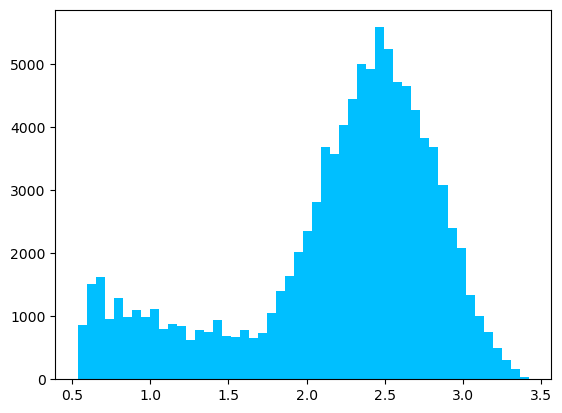

In [8]:
fig, ax = plt.subplots()

ax.hist(variables[:, 1], bins=50, color='deepskyblue');
# ax.legend();